<a href="https://colab.research.google.com/github/SOURAVcse9/Learn_ML/blob/main/tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
arr=np.array([1,2,3])#1D array
arr
arr.ndim

1

In [ ]:
arr=np.array([[1,2,3],[4,5,6]])#2D array
arr.ndim

2

In [ ]:
mat=np.array([[[1,2,3],[4,5,6]],[[7,8,9],[10,11,12]]])#3D array
mat.ndim

3

In [ ]:
arr_4d = np.array([[[[1,2],[3,4]],[[5,6],[7,8]]],[[[9,10],[11,12]],[[13,14],[15,16]]]]) #4D array
print(arr_4d.ndim)

4


Tensor Shape: (1024, 1024, 3)
Tensor Type: <dtype: 'uint8'>


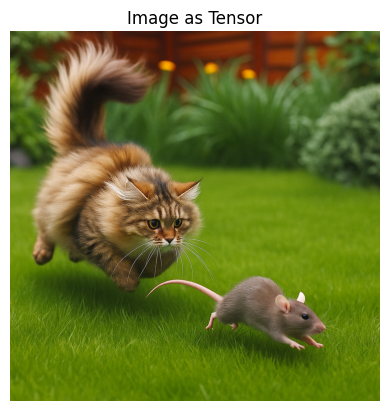

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Image path
image_path = "image.png"

# Read image
image = tf.io.read_file(image_path)

# Convert image to tensor
image_tensor = tf.image.decode_jpeg(image)

# Information
print("Tensor Shape:", image_tensor.shape)
print("Tensor Type:", image_tensor.dtype)

# Display image
plt.imshow(image_tensor)
plt.title("Image as Tensor")
plt.axis("off")
plt.show()

Tensor Creation

Tensor Shape

Rank

Slicing

RGB Channels

Normalization

Resize

Grayscale

Flip

Rotation

Statistics

Batch Dimension

Random Tensor

Tensor Mathematics

Matrix Multiplication

CNN Input Tensor


Feature Maps

Flatten

Dense Layer Output
bold text

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# ==========================
# 1. Load Image as Tensor
# ==========================

image_path = "cat.png"   # তোমার image path

image = tf.io.read_file(image_path)
tensor = tf.image.decode_jpeg(image)

In [14]:
print("\n===== BASIC INFO =====")
print("Shape:", tensor.shape)
print("Datatype:", tensor.dtype)
print("Rank:", tf.rank(tensor).numpy())


===== BASIC INFO =====
Shape: (1024, 1024, 3)
Datatype: <dtype: 'uint8'>
Rank: 3


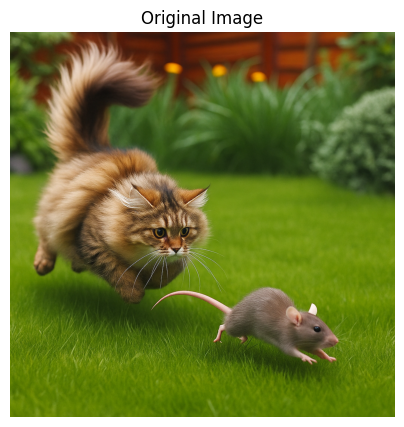

In [15]:
# ==========================
# 2. Show Original Image
# ==========================

plt.figure(figsize=(5,5))
plt.imshow(tensor)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [16]:
# ==========================
# 3. Tensor Shape Analysis
# ==========================

height = tensor.shape[0]
width = tensor.shape[1]
channels = tensor.shape[2]

print("\n===== DIMENSIONS =====")
print("Height:", height)
print("Width :", width)
print("Channels:", channels)


===== DIMENSIONS =====
Height: 1024
Width : 1024
Channels: 3


In [17]:

# ==========================
# 4. Pixel Inspection
# ==========================

print("\n===== PIXEL VALUES =====")

print("Pixel (0,0):", tensor[0,0].numpy())
print("Pixel (100,100):", tensor[100,100].numpy())


===== PIXEL VALUES =====
Pixel (0,0): [56 73 22]
Pixel (100,100): [83 96 39]


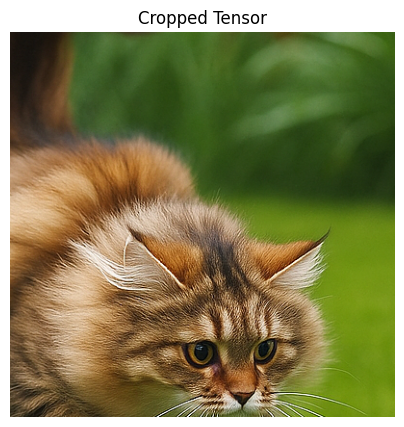

In [18]:
# ==========================
# 5. Tensor Slicing
# ==========================

crop = tensor[200:600, 200:600]

plt.figure(figsize=(5,5))
plt.imshow(crop)
plt.title("Cropped Tensor")
plt.axis("off")
plt.show()

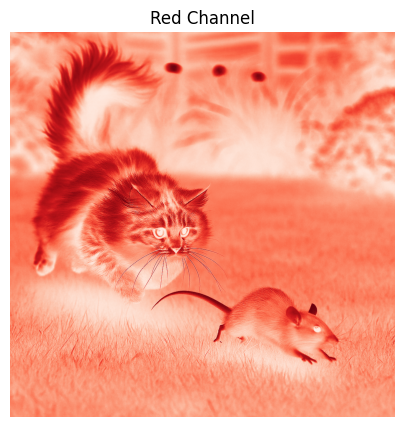

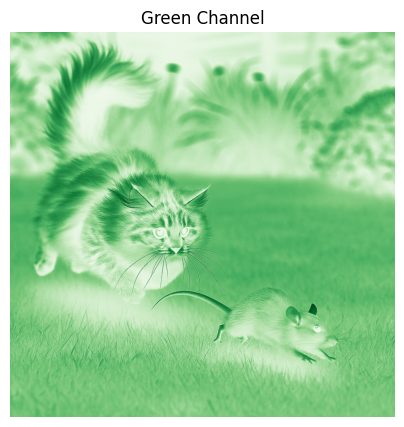

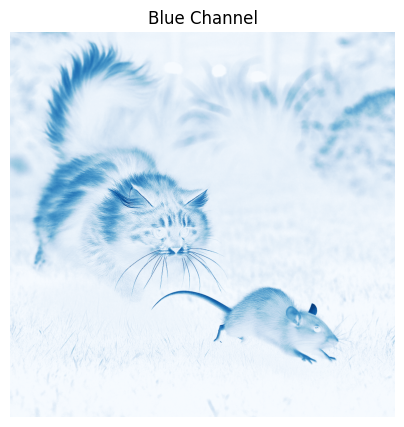

In [19]:
# ==========================
# 6. RGB Channel Extraction
# ==========================

red = tensor[:,:,0]
green = tensor[:,:,1]
blue = tensor[:,:,2]

plt.figure(figsize=(5,5))
plt.imshow(red, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(green, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(blue, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")
plt.show()

In [20]:
# ==========================
# 7. Normalize Tensor
# ==========================

normalized = tf.cast(tensor, tf.float32)/255.0

print("\n===== NORMALIZATION =====")
print("Before:", tensor[0,0].numpy())
print("After :", normalized[0,0].numpy())


===== NORMALIZATION =====
Before: [56 73 22]
After : [0.21960784 0.28627452 0.08627451]



===== RESIZE =====
New Shape: (224, 224, 3)


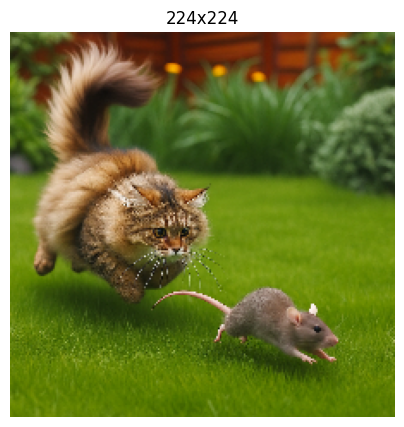

In [21]:

# ==========================
# 8. Resize Tensor
# ==========================

resized = tf.image.resize(tensor, (224,224))

print("\n===== RESIZE =====")
print("New Shape:", resized.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.cast(resized, tf.uint8))
plt.title("224x224")
plt.axis("off")
plt.show()


===== GRAYSCALE =====
Shape: (1024, 1024, 1)


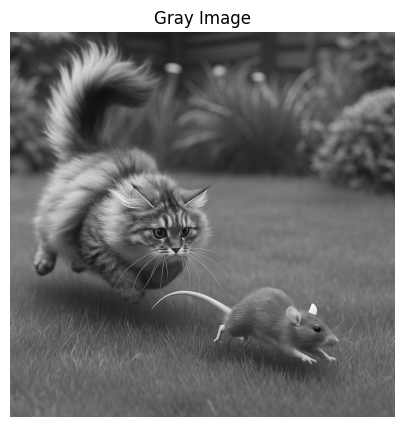

In [22]:

# ==========================
# 9. Grayscale Conversion
# ==========================

gray = tf.image.rgb_to_grayscale(tensor)

print("\n===== GRAYSCALE =====")
print("Shape:", gray.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(gray), cmap="gray")
plt.title("Gray Image")
plt.axis("off")
plt.show()

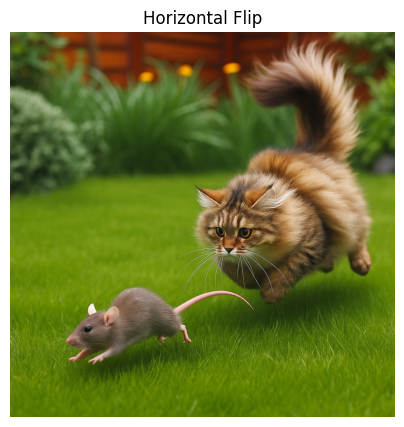

In [23]:
# ==========================
# 10. Flip Tensor
# ==========================

flip = tf.image.flip_left_right(tensor)

plt.figure(figsize=(5,5))
plt.imshow(flip)
plt.title("Horizontal Flip")
plt.axis("off")
plt.show()

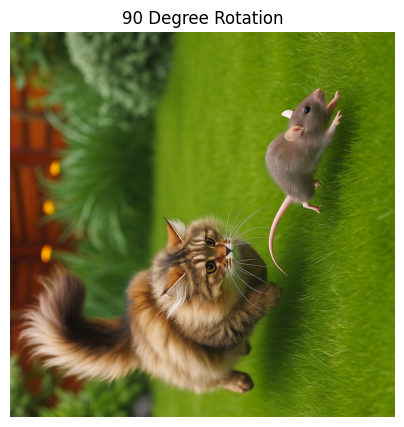

In [24]:

# ==========================
# 11. Rotate Tensor
# ==========================

rotated = tf.image.rot90(tensor)

plt.figure(figsize=(5,5))
plt.imshow(rotated)
plt.title("90 Degree Rotation")
plt.axis("off")
plt.show()

In [25]:

# ==========================
# 12. Tensor Statistics
# ==========================

tensor_float = tf.cast(tensor, tf.float32)

print("\n===== STATISTICS =====")
print("Min :", tf.reduce_min(tensor_float).numpy())
print("Max :", tf.reduce_max(tensor_float).numpy())
print("Mean:", tf.reduce_mean(tensor_float).numpy())


===== STATISTICS =====
Min : 0.0
Max : 255.0
Mean: 79.42121


In [26]:
# ==========================
# 13. Batch Dimension
# ==========================

batch = tf.expand_dims(tensor, axis=0)

print("\n===== BATCH =====")
print("Single Image:", tensor.shape)
print("Batch Shape :", batch.shape)

# CNN Input Format:
# (batch_size, height, width, channels)


===== BATCH =====
Single Image: (1024, 1024, 3)
Batch Shape : (1, 1024, 1024, 3)


In [27]:
# ==========================
# 14. Create Random Tensor
# ==========================

random_tensor = tf.random.normal((3,3))

print("\n===== RANDOM TENSOR =====")
print(random_tensor)


===== RANDOM TENSOR =====
tf.Tensor(
[[ 0.8416224   1.4489963   0.9757336 ]
 [ 0.68295556 -0.02065616  0.08761095]
 [-0.29633108  0.12252776  0.6570134 ]], shape=(3, 3), dtype=float32)


In [28]:
# ==========================
# 15. Tensor Math
# ==========================

a = tf.constant([[1.,2.],[3.,4.]])
b = tf.constant([[5.,6.],[7.,8.]])

print("\n===== TENSOR MATH =====")

print("Addition:")
print(tf.add(a,b))

print("\nSubtraction:")
print(tf.subtract(a,b))

print("\nMultiplication:")
print(tf.multiply(a,b))

print("\nMatrix Multiplication:")
print(tf.matmul(a,b))


===== TENSOR MATH =====
Addition:
tf.Tensor(
[[ 6.  8.]
 [10. 12.]], shape=(2, 2), dtype=float32)

Subtraction:
tf.Tensor(
[[-4. -4.]
 [-4. -4.]], shape=(2, 2), dtype=float32)

Multiplication:
tf.Tensor(
[[ 5. 12.]
 [21. 32.]], shape=(2, 2), dtype=float32)

Matrix Multiplication:
tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)


In [29]:
# ==========================
# 16. CNN Example
# ==========================

cnn_input = tf.expand_dims(
    tf.cast(resized, tf.float32)/255.0,
    axis=0
)

conv = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3,3),
    activation='relu'
)

feature_map = conv(cnn_input)

print("\n===== CNN FEATURE MAP =====")
print("Input Shape :", cnn_input.shape)
print("Output Shape:", feature_map.shape)


===== CNN FEATURE MAP =====
Input Shape : (1, 224, 224, 3)
Output Shape: (1, 222, 222, 8)


In [30]:

# ==========================
# 17. Flatten Tensor
# ==========================

flatten = tf.keras.layers.Flatten()

flat = flatten(feature_map)

print("\n===== FLATTEN =====")
print("Shape:", flat.shape)


===== FLATTEN =====
Shape: (1, 394272)


In [31]:
# ==========================
# 18. Dense Layer
# ==========================

dense = tf.keras.layers.Dense(10)

output = dense(flat)

print("\n===== FINAL OUTPUT =====")
print("Shape:", output.shape)

print("\nProject Completed Successfully!")


===== FINAL OUTPUT =====
Shape: (1, 10)

Project Completed Successfully!
